# 导论·3 从系统问题走向计算与证据

## 学习目标与先修知识

- 比较相同人数、联系数下，不同连接方式产生的传播过程。
- 按同步规则手算并实现逐轮传递，解释代码与人工枚举的对应。
- 判断实验支持的结论及进一步需要的证据，并定位后续学习内容。

**先修知识**：[导论·1](01-从生命现象认识系统.ipynb)和[导论·2](02-系统科学关心什么如何发展.ipynb)的问题视角；中学计数；重现代码需 Python 列表、循环与函数。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 提出一个可以核对的问题

六个个体 A—F 都能把消息传给与自己直接联系的人。两组都有六个个体、五条双向联系，第一组排成一条链，第二组由 A 联系其余五人。**同样从 A 开始，前三轮到达的人数是否相同？**

| 连接方式 | 全部联系 |
|---|---|
| 链形 | A—B、B—C、C—D、D—E、E—F |
| 星形 | A—B、A—C、A—D、A—E、A—F |

这里把传递过程写成一个模型（model）：每条联系每轮都能成功传递；联系不变；收到消息后一直保留。第 0 轮只有起点收到消息。每一轮只允许**上一轮已经收到消息的人**向邻居传递，本轮新收到的人要等下一轮才能再传递。这叫同步更新（synchronous update）。图上的线长不表示距离或耗时。

## 先手工枚举

链形从 A 出发，第 1 轮 B 收到，第 2 轮 C 收到，第 3 轮 D 收到。星形从中心 A 出发，第 1 轮其余五人都收到，之后没有新的接收者。

| 轮次 | 链形已接收者 | 链形累计人数 | 星形累计人数 |
|---|---|---|---|
| 0 | A | 1 | 1 |
| 1 | A、B | 2 | 6 |
| 2 | A、B、C | 3 | 6 |
| 3 | A、B、C、D | 4 | 6 |

**试着预测**：如果把起点改成 F，星形还会在第一轮到达所有人吗？先沿联系走一轮，再看后面的代码。

## 把明确的规则翻译成代码

代码用 0—5 对应 A—F。一条联系 `(0, 1)` 表示 A 与 B 可以双向传递；六个布尔值记录每人是否收到消息。`history` 保留每轮结束时的名单。

关键是 `previous` 与 `received` 分开：本轮判断谁能发送时始终读取旧名单；新接收者写入新名单。若一边改名单一边拿它继续发送，消息可能在一次循环中走完整条链，那就悄悄改变了题目的轮次含义。

In [1]:
def propagate(edges, start=0, rounds=5):
    received = [False] * 6
    received[start] = True
    history = [received.copy()]
    for _ in range(rounds):
        previous = received.copy()
        for left, right in edges:
            if previous[left]:
                received[right] = True
            if previous[right]:
                received[left] = True
        history.append(received.copy())
    return history

chain = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5)]
star = [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]
chain_history = propagate(chain)
star_history = propagate(star)
chain_counts = [sum(row) for row in chain_history]
star_counts = [sum(row) for row in star_history]
print('链形，含第 0 轮：', chain_counts)
print('星形，含第 0 轮：', star_counts)

链形，含第 0 轮： [1, 2, 3, 4, 5, 6]
星形，含第 0 轮： [1, 6, 6, 6, 6, 6]


## 对照手算，再看完整过程

下面首先核对手算过的前三轮，随后画出第 0—5 轮的人数。图左为链形（Chain），中间为星形（Star）；两幅连接图的字母表示同一组人。右图的横坐标 Round 表示轮次，纵坐标 People reached 表示累计人数，包含起点。

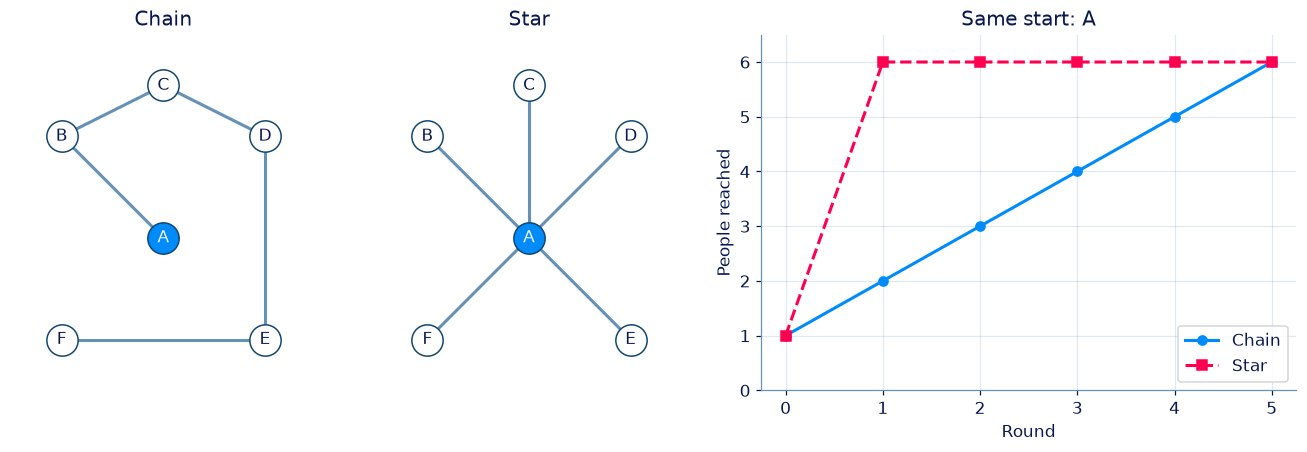

In [2]:
assert chain_counts[:4] == [1, 2, 3, 4]
assert star_counts[:4] == [1, 6, 6, 6]

import matplotlib.pyplot as plt
from systems_science import plot_style

plot_style()
fig, axes = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={'width_ratios':[1,1,1.5]})
positions = [(0, 0), (-1, 1), (0, 1.5), (1, 1), (1, -1), (-1, -1)]
for ax, edges, title in zip(axes[:2], [chain, star], ['Chain', 'Star']):
    for left, right in edges:
        ax.plot([positions[left][0], positions[right][0]],
                [positions[left][1], positions[right][1]], color='#6491b5', zorder=1)
    for i, (x, y) in enumerate(positions):
        ax.scatter(x, y, s=420, color='#008bfb' if i==0 else 'white',
                   edgecolor='#14476f', zorder=2)
        ax.text(x, y, chr(65+i), ha='center', va='center', color='white' if i==0 else '#081950')
    ax.set(xlim=(-1.5,1.5), ylim=(-1.5,2), title=title, aspect='equal')
    ax.axis('off')
axes[2].plot(range(6), chain_counts, 'o-', color='#008bfb', label='Chain')
axes[2].plot(range(6), star_counts, 's--', color='#ff0051', label='Star')
axes[2].set(xlabel='Round', ylabel='People reached', xticks=range(6), yticks=range(7), ylim=(0,6.5), title='Same start: A')
axes[2].legend()
plt.show()

## 改一个条件，检验解释

连接数量相同没有保证结果相同：从 A 出发，前三轮链形只到达四人，星形已经到达六人。这里改变的是谁与谁连接；起点标签相同，但 A 在两种结构中的位置不同。将起点改为叶端 F，可以进一步判断“第一轮覆盖全体”是否依赖 A 的中心位置。

In [3]:
star_from_f = [sum(row) for row in propagate(star, start=5, rounds=3)]
print('星形从 F 出发：', star_from_f)
assert star_from_f == [1, 2, 6, 6]  # F → A → 其余四人

# 不传递或没有联系时，只有起点收到；联系列举的顺序不应改变同步更新。
assert [sum(row) for row in propagate(chain, rounds=0)] == [1]
assert [sum(row) for row in propagate([], rounds=3)] == [1, 1, 1, 1]
assert propagate(list(reversed(chain))) == chain_history

星形从 F 出发： [1, 2, 6, 6]


星形从 F 出发要到第二轮才到达全体。因此本次结果说明的是：**给定传递规则、起点和观察轮次，连接安排会影响传播路径与速度。** 如果真实消息可能丢失，个体会忘记，或联系会随时间改变，就需要修改规则并收集相应证据。

[逐轮探索连接方式与起点](http://127.0.0.1:8000/introduction/explore/)提供同一实验的交互图；上面的循环就是计算规则，手算是独立核对它的依据。

## 应用意义：把共同问题带回具体对象

在物质清除问题中，需要考虑交换与清除的机制，才能解释不同位置的读数。在工程温控中，需要研究观察和动作怎样相互影响，才能比较调节效果。在生态恢复中，需要考虑物种联系、环境和时间尺度（time scale），才能解释干预后的变化。

这些对象都受相互作用影响，但传递的量、时间和规则各有不同。六人实验训练了提问和核对的过程；真正应用时，首先要为对象重新建立关系和证据。完整的系统研究往往在下列步骤之间来回推进：提出问题 → 写清假设 → 建立模型 → 计算预测 → 对照证据 → 修正解释。

## 全书学习地图

| 接下来要建立的能力 | 正式学习位置 |
|---|---|
| 从现象建立模型，理解时间变化、多变量、非线性与随机性 | [第 1—5 篇，从第一篇开始](../01-看见系统/README.md) |
| 从测量认识模型与内部状态（state），建立优化和推断方法 | [第 6 篇](../06-从测量走向模型/README.md)、[第 7 篇](../07-状态估计与贝叶斯滤波/README.md)、[第 8 篇](../08-优化方法与计算/README.md)、[第 9 篇](../09-概率建模与近似推断/README.md) |
| 用反馈（feedback）和优化选择行动 | [第 10 篇](../10-反馈与最优控制/README.md) |
| 理解网络、个体交互、临界变化与韧性 | [第 11 篇](../11-网络上的系统/README.md)、[第 12 篇](../12-个体与集体现象/README.md)、[第 13 篇](../13-临界变化与韧性/README.md) |
| 比较数据驱动、机制融合与学习控制方法 | [第 14 篇](../14-数据驱动动力学与模型降阶/README.md)、[第 15 篇](../15-可微分建模与机制融合/README.md)、[第 16 篇](../16-自适应、鲁棒与学习控制/README.md) |
| 用复现、基线与失效分析形成研究证据 | [第 17 篇](../17-研究复现与综合实践/README.md) |

地图帮助我们知道方法将在哪里展开。接下来按顺序进入 1.1：先学会把问题中的对象、内部情况和读数区分清楚，再逐步建立数学与算法。导论自测用于发现需要回看的概念，可以随时继续学习。

[继续：1.1.1 边界、状态与观测](../01-看见系统/01-从生理现象提出系统问题/01-边界状态与观测.ipynb) · [导论导览](http://127.0.0.1:8000/introduction/)

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：独立判断前三轮

六人链 A—B—C—D—E—F 的联系均为双向。第 0 轮只有 A 收到消息。每轮仅由上一轮已收到消息者传给相邻者，收到后保持。第 1、2、3 轮的累计接收人数（含 A）分别是多少？

- **A.** 2、3、4。
- **B.** 6、6、6。
- **C.** 1、2、3。
- **D.** 2、4、6。

[作答：独立判断前三轮](http://127.0.0.1:8000/introduction/practice/?question=p00-rounds)

### 第 2 题 · 多项选择题：实验支持多大的结论

六人链 A—B—C—D—E—F 与以 A 为中心、连接其余五人的六人星形，联系均为双向。第 0 轮仅 A 收到消息，每轮只由上一轮已收到者传给邻居，收到后保持。第三轮累计人数分别为 4 和 6。哪些结论受到这个实验支持？

- **A.** 在给定规则、起点与观察轮次下，连接方式改变了累计接收人数。
- **B.** 星形连接在所有真实传播问题中都最优，而且没有代价。
- **C.** 要推广到真实传播，还需要了解传递失败、联系变化或个体差异等机制。
- **D.** 人数差异证明了真实生理系统一定采用星形连接。

[作答：实验支持多大的结论](http://127.0.0.1:8000/introduction/practice/?question=p00-evidence)

### 第 3 题 · 单项选择题：找到后续学习位置

学习地图写着：第 1—5 篇建立基础；第 6 篇从测量走向模型（model）；第 7 篇状态（state）估计与贝叶斯滤波（Bayesian filtering）；第 10 篇反馈（feedback）与最优控制；第 17 篇研究复现。一位读者想逐步学习“从有噪声的读数推断内部状态”，哪项安排合理？

- **A.** 先从 1.1 建立基础，并把第 7 篇作为后续专题目标，按先修顺序推进。
- **B.** 把第 17 篇当成所有方法的零基础入口。
- **C.** 只要导论自测通过，就可以认为已经掌握滤波算法。
- **D.** 导论的正确率不足 100% 时，教材应禁止进入 1.1。

[作答：找到后续学习位置](http://127.0.0.1:8000/introduction/practice/?question=p00-route)